# M7: within-subject vs. between-subject variance (variance components)

Implements proposal 3 from `docs/ssvep_analyses.md` (PLAN milestone M7): is
PD's greater spread about the people, or about the measurement? Replaces the
earlier point-estimate within/between SD split with a proper random-intercept
mixed model per group (`variance.py`, `statsmodels` `MixedLM`) and a
subject-level bootstrap CI on each variance component.

**Why one MixedLM per group instead of a single pooled model.** The
alternative -- one model across all subjects, group as a fixed effect on the
mean, and `vc_formula` giving each group its own between-subject variance
component -- is closer to the original proposal's literal wording and would
let you test group differences in variance within one framework. It's also
more complex to build and interpret (it bakes in a shared-residual-variance
assumption across groups), and this project's own earlier finding already
justifies the simpler choice: within-subject CV is roughly flat across
groups, so there's no strong reason to expect a pooled model to change the
answer. Went with the simpler option: fit each group's own model separately,
and use the same subject-level percentile bootstrap this project already used
for PD's raw SD (`docs/ssvep_analyses.md` proposal 3), just applied properly
per group instead of computed by hand on group-collapsed numbers.

In [1]:
import sys
sys.path.append('../scripts')

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis as an
import variance as vr
from plotting import DISTRIBUTION_COLOR

runmap_df = an.load_runmap()
baselines_df = an.load_baselines()
metadata_df = an.load_metadata()

SESSION = 1
categories = [
    {'label': 'PD', 'group': 'PD'},
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

# statsmodels' gradient-based MixedLM fit occasionally emits a
# ConvergenceWarning on a bootstrap resample that happens to be degenerate
# (e.g. one subject drawn many times); variance.variance_components already
# drops those resamples from the CI rather than trusting a bad fit, so the
# warning itself is just noise here.
warnings.filterwarnings('ignore', category=UserWarning)

## Fit each group's variance components

`variance.group_run_values` gives each subject's per-run overall response
level (mean of that run's percent-change grid); `variance.variance_components`
fits the random-intercept MixedLM and bootstraps the CI on both variance
components (`n_boot=2000`, matching this project's established bootstrap
convention -- takes roughly a minute or two to run across all four groups).

In [2]:
rows = []
for cat in categories:
    values = vr.group_run_values(runmap_df, baselines_df, metadata_df, SESSION,
                                  group=cat.get('group'), subgroup=cat.get('subgroup'))
    result = vr.variance_components(values, n_boot=2000, seed=0)
    rows.append({'label': cat['label'], 'n': result['n_subjects'],
                 'within_sd': result['within_sd'], 'within_ci': result['within_ci'],
                 'between_sd': result['between_sd'], 'between_ci': result['between_ci'],
                 'n_boot_used': result['n_boot_used']})

components_df = pd.DataFrame(rows)
components_df

,label,n,within_sd,within_ci,between_sd,between_ci,n_boot_used
0,PD,6,0.103855,"(0.053241266807464355, 0.14620604056381759)",0.414300,"(0.12350590691836608, 0.5610947846699836)",2000
1,HC,21,0.141842,"(0.09365113521795589, 0.19899131698977168)",0.281561,"(0.18692122995020574, 0.35023344390168154)",2000
2,protan,8,0.108935,"(0.07885662393455094, 0.1319380962002477)",0.194149,"(0.09689994994798144, 0.23017648286109943)",2000
3,deutan,7,0.085469,"(0.059528831596618655, 0.11343693270874451)",0.090568,"(2.968096683978886e-06, 0.13202823252284826)",2000


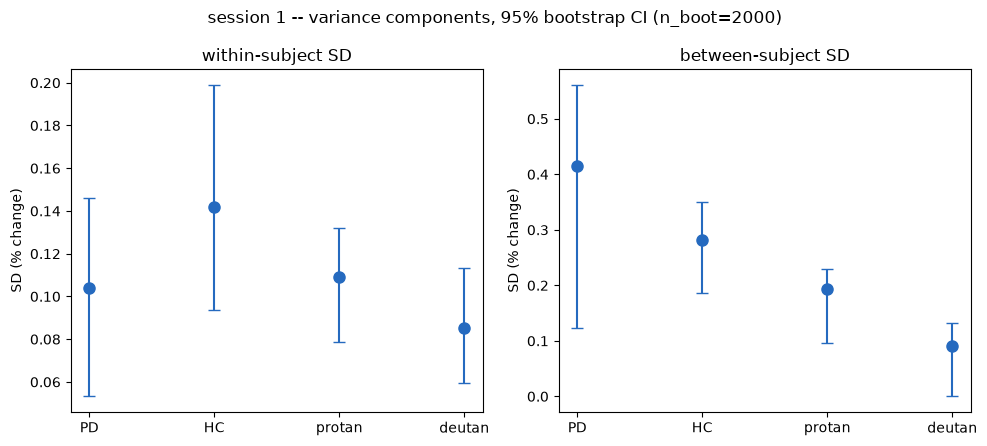

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True)
x = np.arange(len(components_df))
panels = [('within_sd', 'within_ci', 'within-subject SD'), ('between_sd', 'between_ci', 'between-subject SD')]
for ax, (sd_col, ci_col, title) in zip(axes, panels):
    point = components_df[sd_col].to_numpy()
    ci_lo = components_df[ci_col].apply(lambda ci: ci[0]).to_numpy()
    ci_hi = components_df[ci_col].apply(lambda ci: ci[1]).to_numpy()
    ax.errorbar(x, point, yerr=[point - ci_lo, ci_hi - point], fmt='o', color=DISTRIBUTION_COLOR, capsize=4, markersize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(components_df['label'])
    ax.set_title(title)
    ax.set_ylabel('SD (% change)')
fig.suptitle(f'session {SESSION} -- variance components, 95% bootstrap CI (n_boot=2000)')
fig.tight_layout()

**Within-subject SD:** PD (0.104) is not elevated relative to CTR (0.142) --
if anything lower. This confirms proposal 3's original claim on a proper
footing: PD subjects are individually just as internally consistent as
controls. Whatever spread PD shows is not run-to-run noise.

**Between-subject SD:** PD's point estimate (0.414) is the highest of the
four groups, but its CI ([0.12, 0.56]) is wide and overlaps CTR's ([0.19,
0.35]) entirely -- consistent with proposal 3's original conclusion:
**PD is not established as more variable on this evidence**, at n=6.

**The new result this proper model surfaces:** deutan's between-subject SD
(0.091, CI [0.000003, 0.132]) does **not** overlap CTR's CI ([0.19, 0.35]) --
deutan subjects are, on this evidence, *more* homogeneous with each other
than CTR subjects are, not less. That's the opposite direction from the
"neurological condition increases heterogeneity" framing that motivated this
analysis. Worth treating as a real, reportable finding rather than
explaining away -- though also worth remembering deutan is n=7, so this
should be revisited as more session data comes in, same as everything else
in this dataset's smaller groups. Protan's between-subject SD (0.194, CI
[0.10, 0.23]) sits between CTR and deutan and overlaps CTR.

## Within-subject coefficient of variation: is the "not elevated" finding just about response size?

Raw within-subject SD can be misleading on its own -- noise scales with
response size, so a group with a smaller average response could show a
smaller SD without actually being more *consistent*. CV (SD/|mean|, per
subject) corrects for that.

In [4]:
cv_rows = []
for cat in categories:
    values = vr.group_run_values(runmap_df, baselines_df, metadata_df, SESSION,
                                  group=cat.get('group'), subgroup=cat.get('subgroup'))
    cvs = list(vr.within_subject_cv(values).values())
    cv_rows.append({'label': cat['label'], 'n': len(cvs), 'median_cv': np.median(cvs),
                     'min': np.min(cvs), 'max': np.max(cvs)})
pd.DataFrame(cv_rows)

,label,n,median_cv,min,max
0,PD,6,0.172766,0.071457,0.736480
1,HC,21,0.186736,0.026446,0.533353
2,protan,8,0.211623,0.075892,0.745672
3,deutan,7,0.234442,0.112551,0.541121


Median within-subject CV: CTR 0.19, PD 0.17, protan 0.21, deutan 0.23 --
roughly flat, PD if anything the *lowest*. This is a different (and cleaner)
computation than the project's earlier ad hoc CV numbers, so don't expect an
exact match to those -- but it lands on the same qualitative conclusion:
within-subject noise, scale-corrected, doesn't distinguish these groups.
Whatever the between-subject story turns out to be (see above), it is not
being driven by the within-subject axis in any group, including deutan's
unexpectedly low between-subject spread.

## What would sharpen this

Every between-subject SD estimate above comes from a small group (n=6 to
n=21) and reflects whatever heterogeneity exists in *this* sample, with no
way to attribute it to anything in particular. If PD's spread (or deutan's
compression) is real, the natural next step is covariates that could explain
it directly rather than just re-estimating the same variance with more
subjects: for PD, disease severity, duration, and dopaminergic medication
state (all plausibly affecting retinal dopamine and hence contrast response);
for CVD, a quantitative severity/type score rather than the current
protan/deutan binary. None of that data is in this dataset today -- collecting
it is the highest-value addition if this line of analysis is worth pursuing
further, the same conclusion `docs/ssvep_analyses.md` proposal 3 reached
before this notebook existed.